In [1]:
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import v2
from torchvision import models
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision.transforms.functional import to_pil_image
from torchmetrics import MeanMetric, Accuracy
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall, F1Score

In [2]:
device = "cuda" if torch.cuda.is_available() \
          else "mps" if torch.mps.is_available() \
          else "cpu"
print("Device:", device)

Device: cuda


In [3]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
DATA_DIR = "/kaggle/input/datasets/daphn3/dfuc2021/DFU"

train_csv = os.path.join(DATA_DIR, "DFUC2021_train", "train.csv")
train_image_dir = os.path.join(DATA_DIR, "DFUC2021_train", "images")
test_image_dir = os.path.join(DATA_DIR, "DFUC2021_test")

In [5]:
print(train_csv)
print(os.path.exists(train_csv))

print(train_image_dir)
print(os.path.exists(train_image_dir))

print(test_image_dir)
print(os.path.exists(test_image_dir))

/kaggle/input/datasets/daphn3/dfuc2021/DFU/DFUC2021_train/train.csv
True
/kaggle/input/datasets/daphn3/dfuc2021/DFU/DFUC2021_train/images
True
/kaggle/input/datasets/daphn3/dfuc2021/DFU/DFUC2021_test
True


In [6]:
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if "pseudo" in file.lower() and file.endswith(".csv"):
            print(os.path.join(root, file))

/kaggle/input/datasets/daphn3/efficientnet-b3-all-pseudo-labels-csv/efficientnet_b3_all_pseudo_labels.csv


In [7]:
PSEUDO_PATH = "/kaggle/input/datasets/daphn3/efficientnet-b3-all-pseudo-labels-csv/efficientnet_b3_all_pseudo_labels.csv"

In [8]:
train_df = pd.read_csv(train_csv)

train_df.head()

,image,none,infection,ischaemia,both
0,301000.jpg,1.0,0.0,0.0,0.0
1,301001.jpg,1.0,0.0,0.0,0.0
2,301002.jpg,0.0,1.0,0.0,0.0
3,301003.jpg,0.0,1.0,0.0,0.0
4,301004.jpg,0.0,1.0,0.0,0.0


In [9]:
label_cols = ["none", "infection", "ischaemia", "both"]
class_names = ["none", "infection", "ischaemia", "both"]

In [10]:
labelled_df = train_df[train_df[label_cols].notna().any(axis=1)].copy()
unlabelled_df = train_df[train_df[label_cols].isna().all(axis=1)].copy()

In [11]:
labelled_df["label"] = labelled_df[label_cols].values.argmax(axis=1)

In [12]:
print("Labelled:", len(labelled_df))
print("Unlabelled:", len(unlabelled_df))
print(labelled_df["label"].value_counts().sort_index())

Labelled: 5955
Unlabelled: 3994
label
0    2552
1    2555
2     227
3     621
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

train_split_df, val_df = train_test_split(
    labelled_df,
    test_size=0.10,
    random_state=seed,
    stratify=labelled_df["label"])

In [14]:
train_split_df = train_split_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training:", len(train_split_df))
print("Validation:", len(val_df))

print("\nTraining class distribution:")
print(
    train_split_df["label"]
    .value_counts()
    .sort_index())

Training: 5359
Validation: 596

Training class distribution:
label
0    2297
1    2299
2     204
3     559
Name: count, dtype: int64


In [15]:
pseudo_labels_df = pd.read_csv(
    PSEUDO_PATH
)

print("Shape:", pseudo_labels_df.shape)
print(pseudo_labels_df.columns.tolist())

Shape: (3994, 8)
['image', 'pseudo_label', 'pseudo_class', 'confidence', 'prob_none', 'prob_infection', 'prob_ischaemia', 'prob_both']


In [16]:
assert len(pseudo_labels_df) == 3994
assert pseudo_labels_df["image"].is_unique

print("Pseudo-label file looks correct.")

Pseudo-label file looks correct.


In [17]:
pseudo_097_df = pseudo_labels_df[
    pseudo_labels_df["confidence"] >= 0.97
].copy()

pseudo_097_df["label"] = (
    pseudo_097_df["pseudo_label"]
    .astype(int)
)

print(
    "Total pseudo-labels retained:",
    len(pseudo_097_df)
)

print("\nClass distribution:")
print(
    pseudo_097_df["pseudo_class"]
    .value_counts()
)

Total pseudo-labels retained: 2554

Class distribution:
pseudo_class
none         1457
infection    1017
both           42
ischaemia      38
Name: count, dtype: int64


In [18]:
pseudo_097_df.to_csv(
    "/kaggle/working/pseudo_labels_097_augmentation.csv",
    index=False
)

In [19]:
train_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=20),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [20]:
minority_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),

    v2.RandomVerticalFlip(p=0.5),

    v2.RandomAffine(
        degrees=30,
        translate=(0.05, 0.05),
        scale=(0.90, 1.10),
        shear=(-10, 10)
    ),

    v2.ColorJitter(
        brightness=0.10,
        contrast=0.10,
        saturation=0.05
    ),

    v2.ToImage(),

    v2.ToDtype(
        torch.float32,
        scale=True
    ),

    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [21]:
test_transform = v2.Compose([
    v2.ToImage(),

    v2.ToDtype(
        torch.float32,
        scale=True
    ),

    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [22]:
genuine_train_df = train_split_df[
    ["image", "label"]
].copy()

genuine_train_df["transform_type"] = "standard"
genuine_train_df["source"] = "genuine"

print(genuine_train_df.shape)

(5359, 4)


In [23]:
pseudo_train_df = pseudo_097_df[
    ["image", "label"]
].copy()

pseudo_train_df["transform_type"] = "standard"
pseudo_train_df["source"] = "pseudo_097"

print(
    "Pseudo-labelled training rows:",
    len(pseudo_train_df)
)

Pseudo-labelled training rows: 2554


# create additional ischaemia copies
8 extra augmented instances per genuine Ischaemia training image.

In [24]:
ischaemia_genuine = train_split_df[
    train_split_df["label"] == 2
][["image", "label"]].copy()

print(
    "Genuine Ischaemia images:",
    len(ischaemia_genuine)
)

Genuine Ischaemia images: 204


In [25]:
ischaemia_augmented = pd.concat(
    [
        ischaemia_genuine.copy()
        for _ in range(8)
    ],
    ignore_index=True
)

ischaemia_augmented[
    "transform_type"
] = "minority"

ischaemia_augmented[
    "source"
] = "augmented_ischaemia"

print(
    "Additional Ischaemia rows:",
    len(ischaemia_augmented)
)

Additional Ischaemia rows: 1632


# create additional both copies
3 extra augmented instances per genuine Both image.

In [26]:
both_genuine = train_split_df[
    train_split_df["label"] == 3
][["image", "label"]].copy()

print(
    "Genuine Both images:",
    len(both_genuine)
)

Genuine Both images: 559


In [27]:
both_augmented = pd.concat(
    [
        both_genuine.copy()
        for _ in range(3)
    ],
    ignore_index=True
)

both_augmented[
    "transform_type"
] = "minority"

both_augmented[
    "source"
] = "augmented_both"

print(
    "Additional Both rows:",
    len(both_augmented)
)

Additional Both rows: 1677


In [28]:
train_aug_df = pd.concat(
    [
        genuine_train_df,
        pseudo_train_df,
        ischaemia_augmented,
        both_augmented
    ],
    ignore_index=True
)

print(
    "Total training instances:",
    len(train_aug_df)
)

print("\nRows by source:")
print(
    train_aug_df["source"]
    .value_counts()
)

print("\nEffective class distribution:")
print(
    train_aug_df["label"]
    .value_counts()
    .sort_index()
)

Total training instances: 11222

Rows by source:
source
genuine                5359
pseudo_097             2554
augmented_both         1677
augmented_ischaemia    1632
Name: count, dtype: int64

Effective class distribution:
label
0    3754
1    3316
2    1874
3    2278
Name: count, dtype: int64


In [29]:
train_aug_df.to_csv(
    "/kaggle/working/augmentation_training_manifest.csv",
    index=False
)

In [30]:
overlap = set(
    train_aug_df["image"]
).intersection(
    set(val_df["image"])
)

print(
    "Validation overlap:",
    len(overlap)
)

assert len(overlap) == 0

Validation overlap: 0


# Dataset class for the augmentation experiment

In [31]:
class DFUAugmentationDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        standard_transform,
        minority_transform
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.image_dir = image_dir

        self.standard_transform = (
            standard_transform
        )

        self.minority_transform = (
            minority_transform
        )

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = os.path.join(
            self.image_dir,
            row["image"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        label = int(
            row["label"]
        )

        if (
            row["transform_type"]
            == "minority"
        ):

            image = (
                self.minority_transform(
                    image
                )
            )

        else:

            image = (
                self.standard_transform(
                    image
                )
            )

        return (
            image,
            torch.tensor(
                label,
                dtype=torch.long
            )
        )

In [32]:
class DFUDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        transform=None
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = os.path.join(
            self.image_dir,
            row["image"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        label = int(
            row["label"]
        )

        if self.transform:
            image = self.transform(
                image
            )

        return (
            image,
            torch.tensor(
                label,
                dtype=torch.long
            )
        )

In [33]:
BATCH_SIZE = 16

train_aug_dataset = DFUAugmentationDataset(
    train_aug_df,
    train_image_dir,
    standard_transform=train_transform,
    minority_transform=minority_transform
)

val_dataset = DFUDataset(
    val_df,
    train_image_dir,
    transform=test_transform
)

In [34]:
train_loader = DataLoader(
    train_aug_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "Training instances:",
    len(train_aug_dataset)
)

print(
    "Validation images:",
    len(val_dataset)
)

Training instances: 11222
Validation images: 596


In [35]:
assert len(labelled_df) == 5955
assert len(unlabelled_df) == 3994

assert len(train_split_df) == 5359
assert len(val_df) == 596

assert len(overlap) == 0

assert (
    pseudo_097_df["confidence"] >= 0.97
).all()

assert (
    train_aug_df[
        train_aug_df["source"]
        == "augmented_ischaemia"
    ]["label"] == 2
).all()

assert (
    train_aug_df[
        train_aug_df["source"]
        == "augmented_both"
    ]["label"] == 3
).all()

print(
    "All checks passed — ready to train."
)

All checks passed — ready to train.


In [36]:
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [37]:
model = models.efficientnet_b3(
    weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    4
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 188MB/s]


In [38]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [39]:
def train_one_epoch(
    model,
    dataloader
):

    losses = MeanMetric().to(device)

    acc = Accuracy(
        task="multiclass",
        num_classes=4
    ).to(device)

    model.train()

    for X, Y in tqdm(dataloader):

        X = X.to(device)
        Y = Y.to(device)

        preds = model(X)

        loss = criterion(
            preds,
            Y
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        preds = preds.argmax(
            dim=1
        )

        losses.update(
            loss,
            X.size(0)
        )

        acc.update(
            preds,
            Y
        )

    return (
        losses.compute().item(),
        acc.compute().item()
    )

In [40]:
def validation_one_epoch(
    model,
    dataloader
):

    losses = MeanMetric().to(device)

    acc = Accuracy(
        task="multiclass",
        num_classes=4
    ).to(device)

    model.eval()

    with torch.no_grad():

        for X, Y in tqdm(dataloader):

            X = X.to(device)
            Y = Y.to(device)

            preds = model(X)

            loss = criterion(
                preds,
                Y
            )

            preds = preds.argmax(
                dim=1
            )

            losses.update(
                loss,
                X.size(0)
            )

            acc.update(
                preds,
                Y
            )

    return (
        losses.compute().item(),
        acc.compute().item()
    )

In [41]:
history_aug = pd.DataFrame()

best_val_acc = 0.0
best_epoch = 0

epochs = 100

patience = 8
epochs_no_improve = 0

min_delta = 0.0001

scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.1,
        patience=5
    )
)
 

for i in range(epochs):

    train_loss, train_acc = (
        train_one_epoch(
            model,
            train_loader
        )
    )

    val_loss, val_acc = (
        validation_one_epoch(
            model,
            val_loader
        )
    )

    scheduler.step(
        val_acc
    )

    if (
        val_acc
        > best_val_acc + min_delta
    ):

        best_val_acc = val_acc
        best_epoch = i + 1
        epochs_no_improve = 0

        torch.save(
            model.state_dict(),
            "/kaggle/working/"
            "best_efficientnetb3_augmented.pth"
        )

    else:

        epochs_no_improve += 1

    statistics = pd.DataFrame({
        "epoch":
            [i + 1],

        "train_loss":
            [train_loss],

        "train_acc":
            [train_acc],

        "val_loss":
            [val_loss],

        "val_acc":
            [val_acc],

        "learning_rate":
            [
                optimizer
                .param_groups[0]["lr"]
            ]
    })

    history_aug = pd.concat(
        [
            history_aug,
            statistics
        ],
        ignore_index=True
    )

    history_aug.to_csv(
        "/kaggle/working/"
        "history_efficientnetb3_augmented.csv",
        index=False
    )

    print(
        statistics
        .to_dict(
            orient="records"
        )[0]
    )

    if (
        epochs_no_improve
        >= patience
    ):

        print(
            f"Early stopping at epoch {i + 1}"
        )

        break


print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation accuracy:",
    best_val_acc
)

100%|██████████| 38/38 [00:03<00:00,  9.75it/s]


{'epoch': 1, 'train_loss': 0.6880002021789551, 'train_acc': 0.7105685472488403, 'val_loss': 0.7888650894165039, 'val_acc': 0.6912751793861389, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:02<00:00, 13.83it/s]


{'epoch': 2, 'train_loss': 0.5035953521728516, 'train_acc': 0.7962039113044739, 'val_loss': 0.628695547580719, 'val_acc': 0.7265100479125977, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:02<00:00, 14.26it/s]


...

{'epoch': 64, 'train_loss': 0.0277230367064476, 'train_acc': 0.9906433820724487, 'val_loss': 0.30554449558258057, 'val_acc': 0.9110738039016724, 'learning_rate': 1.0000000000000002e-06}


100%|██████████| 38/38 [00:02<00:00, 13.14it/s]


{'epoch': 65, 'train_loss': 0.029175082221627235, 'train_acc': 0.9901978373527527, 'val_loss': 0.3132663667201996, 'val_acc': 0.9060402512550354, 'learning_rate': 1.0000000000000002e-06}


100%|██████████| 38/38 [00:02<00:00, 14.46it/s]

{'epoch': 66, 'train_loss': 0.0288795605301857, 'train_acc': 0.9899305105209351, 'val_loss': 0.3198208212852478, 'val_acc': 0.9110738039016724, 'learning_rate': 1.0000000000000002e-06}
Early stopping at epoch 66
Best epoch: 58
Best validation accuracy: 0.9144295454025269


In [42]:
model.load_state_dict(
    torch.load(
        "/kaggle/working/"
        "best_efficientnetb3_augmented.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)

model.eval()

print(
    "Best augmented model loaded."
)

Best augmented model loaded.


In [43]:
y_true = []
y_pred = []
y_prob = []

model.eval()

with torch.inference_mode():

    for images, labels in tqdm(
        val_loader
    ):

        images = images.to(device)

        outputs = model(
            images
        )

        probabilities = (
            torch.softmax(
                outputs,
                dim=1
            )
        )

        predictions = (
            probabilities
            .argmax(dim=1)
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            predictions
            .cpu()
            .numpy()
        )

        y_prob.extend(
            probabilities
            .cpu()
            .numpy()
        )

100%|██████████| 38/38 [00:02<00:00, 14.85it/s]


In [44]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

In [45]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report
)

In [46]:
macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

per_class_f1 = f1_score(
    y_true,
    y_pred,
    average=None
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

micro_f1 = f1_score(
    y_true,
    y_pred,
    average="micro"
)

y_true_onehot = np.eye(4)[
    y_true
]

micro_auc = roc_auc_score(
    y_true_onehot,
    y_prob,
    average="micro",
    multi_class="ovr"
)

macro_auc = roc_auc_score(
    y_true_onehot,
    y_prob,
    average="macro",
    multi_class="ovr"
)

In [47]:
print(
    "Macro F1:",
    macro_f1
)

for name, score in zip(
    class_names,
    per_class_f1
):

    print(
        f"{name} F1:",
        score
    )

print(
    "Macro Precision:",
    macro_precision
)

print(
    "Macro Recall:",
    macro_recall
)

print(
    "Micro F1:",
    micro_f1
)

print(
    "Micro AUC:",
    micro_auc
)

print(
    "Macro AUC:",
    macro_auc
)

Macro F1: 0.9406447413197353
none F1: 0.90234375
infection F1: 0.905511811023622
ischaemia F1: 0.9787234042553191
both F1: 0.976
Macro Precision: 0.9345295997776543
Macro Recall: 0.947047705170778
Micro F1: 0.9144295302013423
Micro AUC: 0.9884502199600619
Macro AUC: 0.9854825041050757


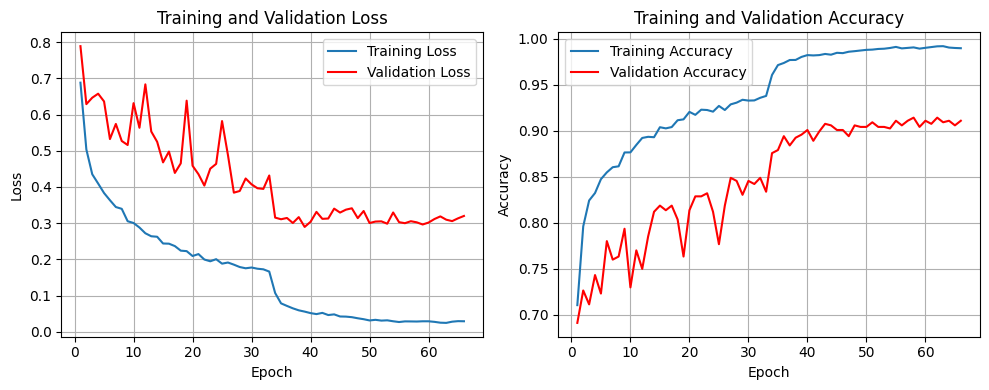

In [48]:
plt.figure(
    figsize=(10, 4)
)

# Loss
plt.subplot(
    1,
    2,
    1
)

plt.plot(
    history_aug["epoch"],
    history_aug["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_aug["epoch"],
    history_aug["val_loss"],
    label="Validation Loss",
    color="red"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid(True)


# Accuracy
plt.subplot(
    1,
    2,
    2
)

plt.plot(
    history_aug["epoch"],
    history_aug["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    history_aug["epoch"],
    history_aug["val_acc"],
    label="Validation Accuracy",
    color="red"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [49]:
model = models.efficientnet_b3(weights=None)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    4
)

model = model.to(device)

model.load_state_dict(
    torch.load(
        "/kaggle/working/best_efficientnetb3_augmented.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

print("Best augmented model loaded.")

Best augmented model loaded.


In [50]:
test_transform = v2.Compose([
    v2.ToImage(),

    v2.ToDtype(
        torch.float32,
        scale=True
    ),

    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [51]:
class DFUTestDataset(Dataset):

    def __init__(
        self,
        image_dir,
        transform=None
    ):

        self.image_dir = image_dir
        self.transform = transform

        self.image_files = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        filename = self.image_files[idx]

        image_path = os.path.join(
            self.image_dir,
            filename
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, filename

In [52]:
test_dataset = DFUTestDataset(
    test_image_dir,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Test images:", len(test_dataset))

Test images: 5734


In [53]:
all_filenames = []
all_probabilities = []

model.eval()

with torch.inference_mode():

    for images, filenames in tqdm(test_loader):

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_filenames.extend(
            filenames
        )

100%|██████████| 359/359 [00:50<00:00,  7.04it/s]


In [54]:
probabilities_array = np.array(
    all_probabilities
)

augmentation_submission = pd.DataFrame({
    "image": all_filenames,
    "none": probabilities_array[:, 0],
    "infection": probabilities_array[:, 1],
    "ischaemia": probabilities_array[:, 2],
    "both": probabilities_array[:, 3]
})

augmentation_submission.head()

,image,none,infection,ischaemia,both
0,501000.jpg,6.624830e-08,9.985036e-01,1.046575e-07,1.496303e-03
1,501001.jpg,1.682702e-04,3.838968e-07,9.921587e-04,9.988392e-01
2,501002.jpg,9.851302e-01,1.486987e-02,1.176227e-09,1.100351e-11
3,501003.jpg,6.898317e-04,9.993101e-01,8.404831e-09,4.362411e-11
4,501004.jpg,5.146998e-05,2.614053e-04,9.996823e-01,4.803263e-06


In [55]:
print(
    "Shape:",
    augmentation_submission.shape
)

print(
    "Columns:",
    augmentation_submission.columns.tolist()
)

print(
    "Missing values:",
    augmentation_submission.isna().sum().sum()
)

print(
    "Duplicate images:",
    augmentation_submission["image"]
    .duplicated()
    .sum()
)

print(
    "Unique images:",
    augmentation_submission["image"]
    .nunique()
)

prob_cols = [
    "none",
    "infection",
    "ischaemia",
    "both"
]

row_sums = augmentation_submission[
    prob_cols
].sum(axis=1)

print(
    "Probability sum minimum:",
    row_sums.min()
)

print(
    "Probability sum maximum:",
    row_sums.max()
)

Shape: (5734, 5)
Columns: ['image', 'none', 'infection', 'ischaemia', 'both']
Missing values: 0
Duplicate images: 0
Unique images: 5734
Probability sum minimum: 0.9999998211860657
Probability sum maximum: 1.0000001192092896


In [56]:
print(
    augmentation_submission[
        prob_cols
    ].min()
)

print(
    augmentation_submission[
        prob_cols
    ].max()
)

none         1.357608e-29
infection    1.262586e-11
ischaemia    5.307755e-18
both         1.105137e-20
dtype: float32
none         1.0
infection    1.0
ischaemia    1.0
both         1.0
dtype: float32


In [57]:
submission_path = (
    "/kaggle/working/"
    "efficientnetb3_augmented_submission.csv"
)

augmentation_submission.to_csv(
    submission_path,
    index=False
)

print("Saved:", submission_path)

Saved: /kaggle/working/efficientnetb3_augmented_submission.csv


In [58]:
mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)


def denormalize_image(image):
    image = image.cpu()
    image = image * std + mean
    image = torch.clamp(image, 0, 1)
    return image

In [59]:

example_row = ischaemia_genuine.sample(
    1,
    random_state=42
).iloc[0]

image_path = os.path.join(
    train_image_dir,
    example_row["image"]
)

original_image = Image.open(
    image_path
).convert("RGB")

print("Image:", example_row["image"])

Image: 301965.jpg


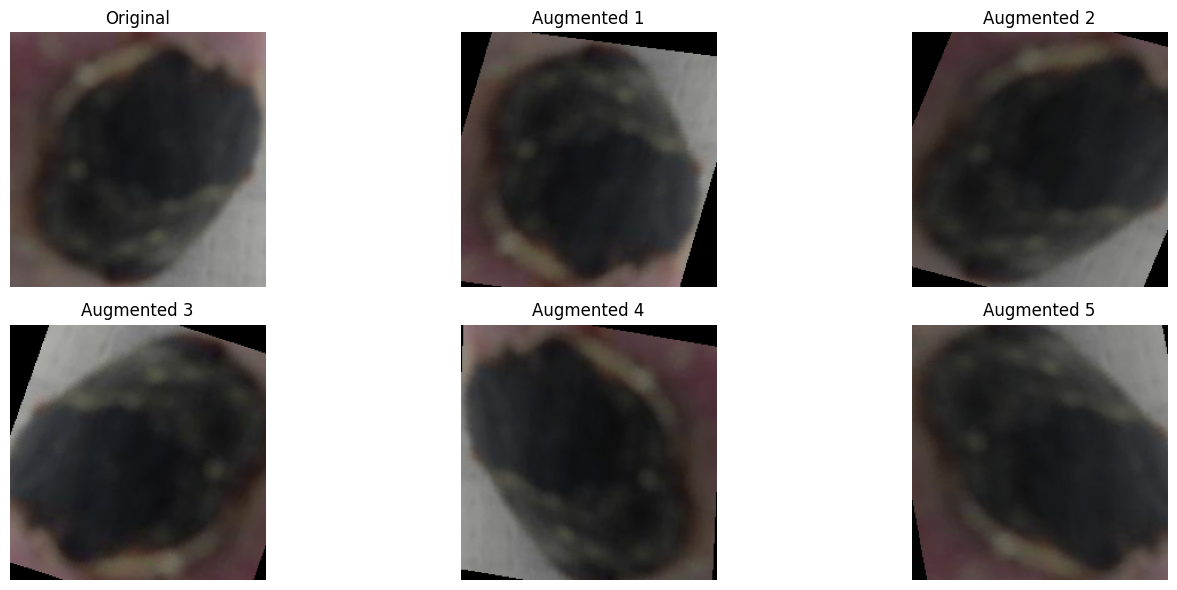

In [60]:
plt.figure(figsize=(15, 6))


plt.subplot(2, 3, 1)

plt.imshow(original_image)
plt.title("Original")
plt.axis("off")



for i in range(5):

    augmented_image = minority_transform(
        original_image.copy()
    )

    augmented_image = denormalize_image(
        augmented_image
    )

    plt.subplot(
        2,
        3,
        i + 2
    )

    plt.imshow(
        augmented_image.permute(
            1, 2, 0
        )
    )

    plt.title(
        f"Augmented {i + 1}"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()

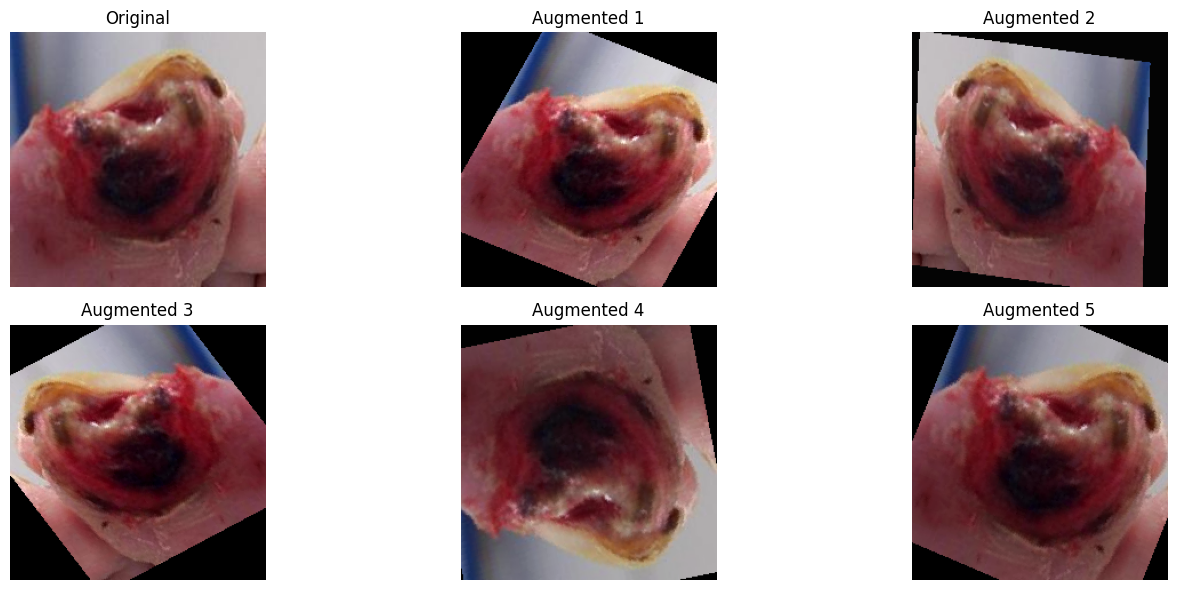

In [61]:
example_row = both_genuine.sample(
    1,
    random_state=42
).iloc[0]

image_path = os.path.join(
    train_image_dir,
    example_row["image"]
)

original_image = Image.open(
    image_path
).convert("RGB")

plt.figure(figsize=(15, 6))

plt.subplot(2, 3, 1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

for i in range(5):

    augmented_image = minority_transform(
        original_image.copy()
    )

    augmented_image = denormalize_image(
        augmented_image
    )

    plt.subplot(
        2,
        3,
        i + 2
    )

    plt.imshow(
        augmented_image.permute(
            1, 2, 0
        )
    )

    plt.title(
        f"Augmented {i + 1}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

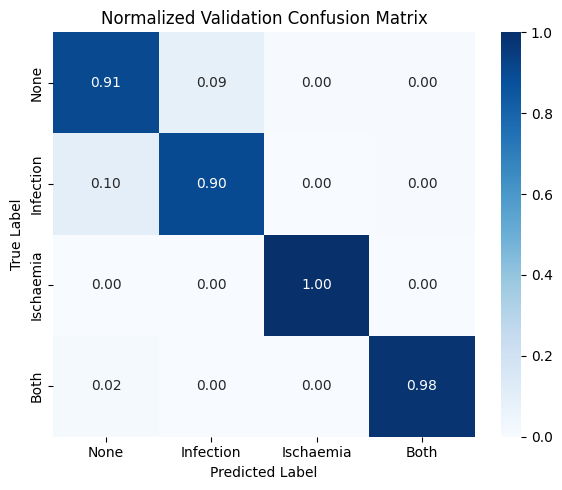

In [63]:
cm_norm = confusion_matrix(
    y_true,
    y_pred,
    normalize="true"
)

classes = ["None", "Infection", "Ischaemia", "Both"]

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    vmin=0,
    vmax=1
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Validation Confusion Matrix")

plt.tight_layout()
plt.show()